# 03 — Análisis Exploratorio de Datos (EDA) global

**Parte I del proyecto.** Exploramos el dataset **completo y sin filtros** (150,346 negocios · 6.99M reseñas · 1.99M usuarios · 13.36M check-ins · 909k tips) para conocer cada variable, evaluar la calidad de los datos y validar con evidencia las decisiones de diseño (universo de restaurantes y los 3 mercados). Recién en el notebook 04 materializamos filtro y recorte.

Organización: (1) diccionario de variables → (2) negocios → (3) usuarios y grafo social → (4) reseñas → (5) check-ins y tips → (6) calidad de datos → (7) resumen.

> Base teórica del curso que este EDA alimenta: muestreo por clave (semana 06), grafos y ranking (semanas 07/12), clustering (semana 08), recomendación (semanas 10/11).

⏱️ ~5–10 min (varias pasadas completas sobre `review`, 7M filas).

In [1]:
import sys
sys.path.append("..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

from src.config import SILVER, spark_session
from src import viz

viz.aplicar_estilo()
spark = spark_session("eda-global")
spark.sparkContext.setLogLevel("ERROR")

T = {t: spark.read.parquet(str(SILVER / f"{t}.parquet"))
     for t in ["business", "review", "user", "tip", "checkin"]}
print({t: f"{df.count():,}" for t, df in T.items()})

26/06/18 13:51:40 WARN Utils: Your hostname, MacBook-Pro-de-johar.local resolves to a loopback address: 127.0.0.1; using 192.168.100.41 instead (on interface en0)
26/06/18 13:51:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/18 13:51:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


{'business': '150,346', 'review': '6,990,280', 'user': '1,987,897', 'tip': '908,915', 'checkin': '13,356,875'}


## 1. Diccionario de variables

Ni el equipo ni el lector conocen esta data de antemano, así que partimos por lo básico: qué es cada columna, cuántos valores le faltan y cuántos valores distintos tiene. La cardinalidad nos dice qué es identificador, qué es categoría y qué es medida.

In [2]:
def diccionario(df, descripciones, max_arr=2):
    """Perfil por columna: tipo, % nulos, cardinalidad y un ejemplo."""
    n = df.count()
    stats = df.select(
        *[F.sum(F.col(c).isNull().cast("int")).alias(f"n_{c}") for c in df.columns],
        *[F.approx_count_distinct(c).alias(f"d_{c}") for c in df.columns],
    ).first()
    ej = df.first()
    filas = []
    for c, dt in df.dtypes:
        v = ej[c]
        if isinstance(v, list): v = v[:max_arr]
        v = str(v); v = v[:60] + "…" if len(v) > 60 else v
        filas.append({"columna": c, "tipo": dt, "% nulos": round(100*stats[f"n_{c}"]/n, 2),
                      "valores distintos": stats[f"d_{c}"], "ejemplo": v,
                      "descripción": descripciones.get(c, "")})
    return pd.DataFrame(filas)

In [3]:
diccionario(T["business"].drop("attributes", "hours"), {
    "business_id": "identificador único del negocio",
    "name": "nombre comercial", "address": "dirección", "city": "ciudad",
    "state": "estado/provincia (2 letras)", "postal_code": "código postal (ZIP en EE.UU.)",
    "latitude": "latitud", "longitude": "longitud",
    "stars": "rating promedio del negocio, redondeado a 0.5",
    "review_count": "nº de reseñas recibidas", "is_open": "1 abierto / 0 cerrado",
    "categories": "lista de categorías (multi-etiqueta)",
    "metro": "área metropolitana (derivada del estado en silver)",
    "es_restaurante": "flag derivado: categoría exacta 'Restaurants'",
})

,columna,tipo,% nulos,valores distintos,ejemplo,descripción
0,address,string,0.00,125266,2842 Saint Vincent St,dirección
1,business_id,string,0.00,154923,x67huqR9qbjoodRBu3KWfg,identificador único del negocio
2,categories,array<string>,0.07,81863,"['Cantonese', 'Grocery']",lista de categorías (multi-etiqueta)
3,city,string,0.00,1373,Philadelphia,ciudad
4,is_open,bigint,0.00,2,1,1 abierto / 0 cerrado
5,latitude,double,0.00,135015,40.0415953142,latitud
6,longitude,double,0.00,127115,-75.0551653732,longitud
7,name,string,0.00,111923,1st NE International Market,nombre comercial
8,postal_code,string,0.00,3355,19149,código postal (ZIP en EE.UU.)
9,review_count,bigint,0.00,1171,6,nº de reseñas recibidas


La tabla maestra está sorprendentemente completa: salvo `categories` (0.07% de nulos), aquí no falta nada — 1,373 ciudades, 28 estados y ~82 mil combinaciones distintas de etiquetas.

Un detalle para no confundirse al leer la columna *valores distintos*: usamos el conteo aproximado de Spark (HyperLogLog, error típico ±2%), por eso `business_id` "aparenta" 154,923 distintos en 150,346 filas. La verificación exacta de duplicados ya la hicimos en el notebook 02 y dio **cero** — preferimos la aproximación aquí porque contar exacto 14 columnas sobre millones de filas no aporta nada nuevo y cuesta minutos.

In [4]:
diccionario(T["review"].drop("text"), {
    "review_id": "identificador de la reseña", "user_id": "autor",
    "business_id": "negocio reseñado", "stars": "calificación 1–5 (entera)",
    "useful": "votos 'útil' recibidos", "funny": "votos 'divertido'",
    "cool": "votos 'cool'", "date": "fecha y hora de publicación",
})

,columna,tipo,% nulos,valores distintos,ejemplo,descripción
0,review_id,string,0.0,7426498,6fObpwIggOQR1oDapyQzyg,identificador de la reseña
1,user_id,string,0.0,1890340,lN-1uUHeV_QyFbczw8ErlA,autor
2,business_id,string,0.0,154923,grpNey31cTGKrhmQQaNGdA,negocio reseñado
3,stars,double,0.0,5,5.0,calificación 1–5 (entera)
4,useful,bigint,0.0,254,0,votos 'útil' recibidos
5,funny,bigint,0.0,202,0,votos 'divertido'
6,cool,bigint,0.0,202,0,votos 'cool'
7,date,timestamp,0.0,6413513,2020-06-28 14:45:32,fecha y hora de publicación


In [5]:
diccionario(T["user"].drop(*[c for c in T["user"].columns if c.startswith("compliment")]), {
    "user_id": "identificador del usuario", "name": "nombre de pila",
    "review_count": "reseñas escritas (histórico de la cuenta)",
    "yelping_since": "fecha de alta en Yelp",
    "useful/funny/cool": "votos recibidos en sus reseñas",
    "friends": "lista de amigos (user_ids) — base del grafo social",
    "fans": "seguidores", "average_stars": "promedio de estrellas que otorga",
    "elite_years": "años con distinción 'Elite' (curada por Yelp)",
    "n_amigos": "derivada: tamaño de friends", "n_elite": "derivada: nº de años elite",
})

,columna,tipo,% nulos,valores distintos,ejemplo,descripción
0,user_id,string,0.0,1890340,kERcdSEyDPbczsFrH_yydw,identificador del usuario
1,name,string,0.0,136493,Adam,nombre de pila
2,review_count,bigint,0.0,1883,15,reseñas escritas (histórico de la cuenta)
3,yelping_since,timestamp,0.0,1898143,2016-07-03 11:48:45,fecha de alta en Yelp
4,useful,bigint,0.0,5131,5,
5,funny,bigint,0.0,3365,3,
6,cool,bigint,0.0,4113,1,
7,friends,array<string>,0.0,985866,"['5-r8vdBoqMoHdHsAMtXw3Q', '816l7A1FwBDXY969eh...",lista de amigos (user_ids) — base del grafo so...
8,fans,bigint,0.0,679,1,seguidores
9,average_stars,double,0.0,403,4.73,promedio de estrellas que otorga


De estas dos tablas nos quedamos con tres ideas. Primero: en `review`, los votos sociales (`useful/funny/cool`) vienen completos para los 7 millones de filas — son señal lista para usar en ranking. Segundo: `friends` ya es un array, así que convertirlo en aristas del grafo social es directo. Tercero: las 11 columnas `compliment_*` que omitimos arriba por espacio son matices de reputación que más adelante resumiremos en una sola métrica.

Y `tip`/`checkin` son tablas de eventos puros — quién, dónde, cuándo — exactamente la forma de un flujo de datos (semana 06): de ahí saldrá nuestra Parte V.

## 2. Negocios: desempeño, giro y geografía


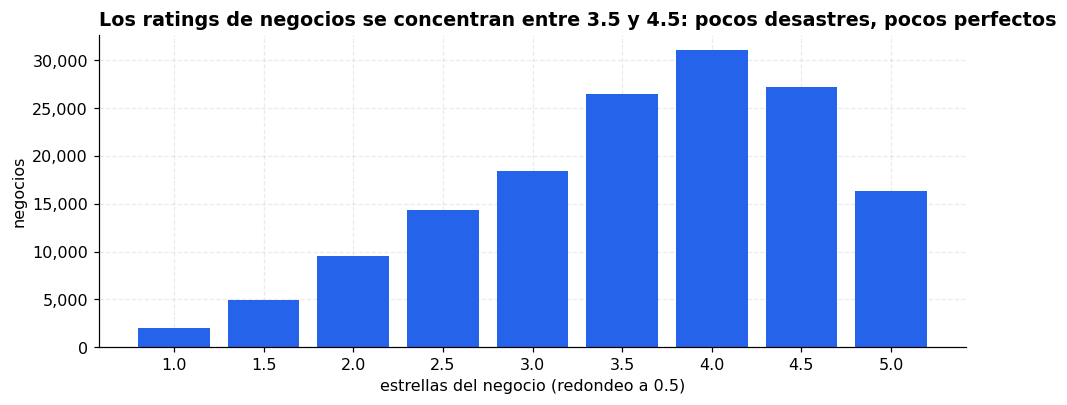

In [6]:
stars_dist = T["business"].groupBy("stars").count().orderBy("stars").toPandas()
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(stars_dist["stars"], stars_dist["count"], width=0.4, color=viz.PALETA["azul"])
viz.fmt_miles(ax)
ax.set_xticks(np.arange(1, 5.5, 0.5))
ax.set_title("Los ratings de negocios se concentran entre 3.5 y 4.5: pocos desastres, pocos perfectos")
ax.set_xlabel("estrellas del negocio (redondeo a 0.5)"); ax.set_ylabel("negocios")
plt.show()

El pico está en 4.0★ (31 mil negocios) y los extremos casi no existen: los locales de 1★ son una rareza — los muy malos cierran o directamente nadie los reseña. Casi todo el catálogo vive entre 3.5 y 4.5.

Para la Parte IV esto tiene una consecuencia práctica: acertar la nota exacta (RMSE) dirá poco cuando todas las notas se parecen; rankear bien el top-K será la prueba de fuego. Por eso evaluaremos las dos familias de métricas que pide el enunciado, pero leeremos con más atención la segunda.

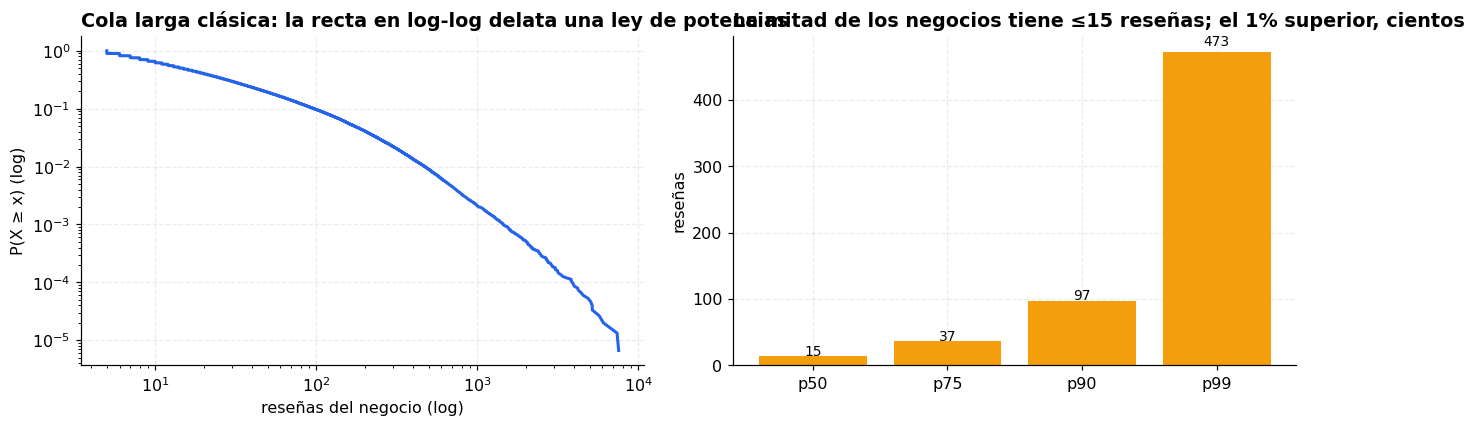

% de negocios con <10 reseñas: 34.0%  |  máximo: 7,568


In [7]:
rc = T["business"].select("review_count").toPandas()["review_count"].values
x, p = viz.ccdf(rc)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].loglog(x, p, color=viz.PALETA["azul"], lw=2)
axes[0].set_title("Cola larga clásica: la recta en log-log delata una ley de potencias")
axes[0].set_xlabel("reseñas del negocio (log)"); axes[0].set_ylabel("P(X ≥ x) (log)")

q = [50, 75, 90, 99]
vals = np.percentile(rc, q)
axes[1].bar([f"p{i}" for i in q], vals, color=viz.PALETA["naranja"])
for i, v in enumerate(vals):
    axes[1].text(i, v * 1.02, f"{v:,.0f}", ha="center", fontsize=9)
axes[1].set_title("La mitad de los negocios tiene ≤15 reseñas; el 1% superior, cientos")
axes[1].set_ylabel("reseñas")
plt.show()
print(f"% de negocios con <10 reseñas: {100*(rc<10).mean():.1f}%  |  máximo: {rc.max():,}")

La mitad de los negocios tiene 15 reseñas o menos; para entrar al 1% más visible hacen falta 473. Esa asimetría —la recta descendente del log-log— es la firma de las plataformas reales.

Dos cosas nos importan de esto. El *cold-start* de la Parte IV no es un caso borde teórico: es la mayoría del catálogo. Y cualquier ranking por conteo bruto lo dominarán los mismos gigantes de siempre — justo lo que PageRank y HITS (semana 07) vienen a corregir con una noción de importancia que mira la estructura, no el volumen.

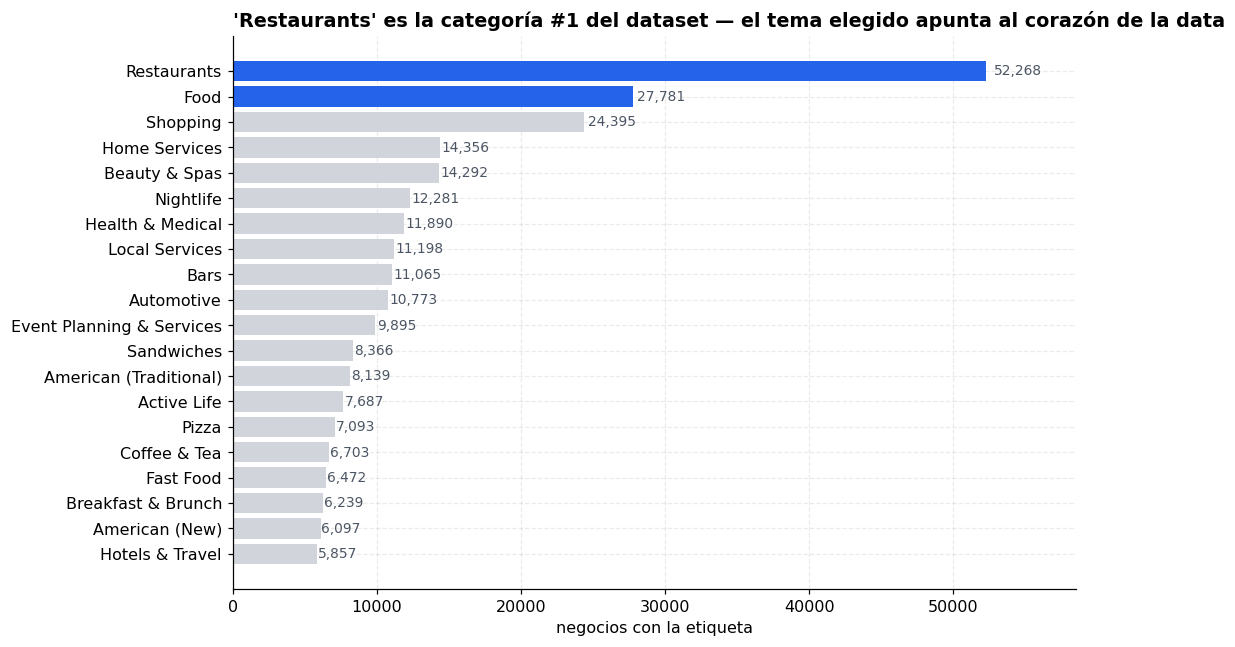

categorías por negocio: media 4.4, mediana 4


In [8]:
cats = (T["business"].select(F.explode("categories").alias("cat"))
        .groupBy("cat").count().orderBy(F.desc("count")).limit(20).toPandas())
ncats = T["business"].select(F.size("categories").alias("n")).where("n is not null")
stats_n = ncats.agg(F.avg("n"), F.expr("percentile(n, 0.5)")).first()

fig, ax = plt.subplots(figsize=(10, 6))
viz.barras_h(ax, cats["cat"][::-1], cats["count"][::-1],
             resaltar={"Restaurants", "Food"})
ax.set_title("'Restaurants' es la categoría #1 del dataset — el tema elegido apunta al corazón de la data")
ax.set_xlabel("negocios con la etiqueta")
plt.show()
print(f"categorías por negocio: media {stats_n[0]:.1f}, mediana {stats_n[1]:.0f}")

`Restaurants` etiqueta 52,268 negocios (35% del total) — es la categoría #1 del dataset — y `Food` 27,781 (18%). Como cada negocio lleva ~4 etiquetas en promedio, ambas conviven con subcategorías como Pizza, Coffee & Tea o Bars.

Esto valida dos decisiones nuestras: el **tema** (elegimos el segmento dominante de la data) y el **filtro**: al ser multi-etiqueta, un café genuinamente gastronómico también porta `Restaurants`, así que el token exacto no lo pierde. La sensibilidad `∪ Food` la cuantificamos en el notebook 04 para cerrar la discusión con números.

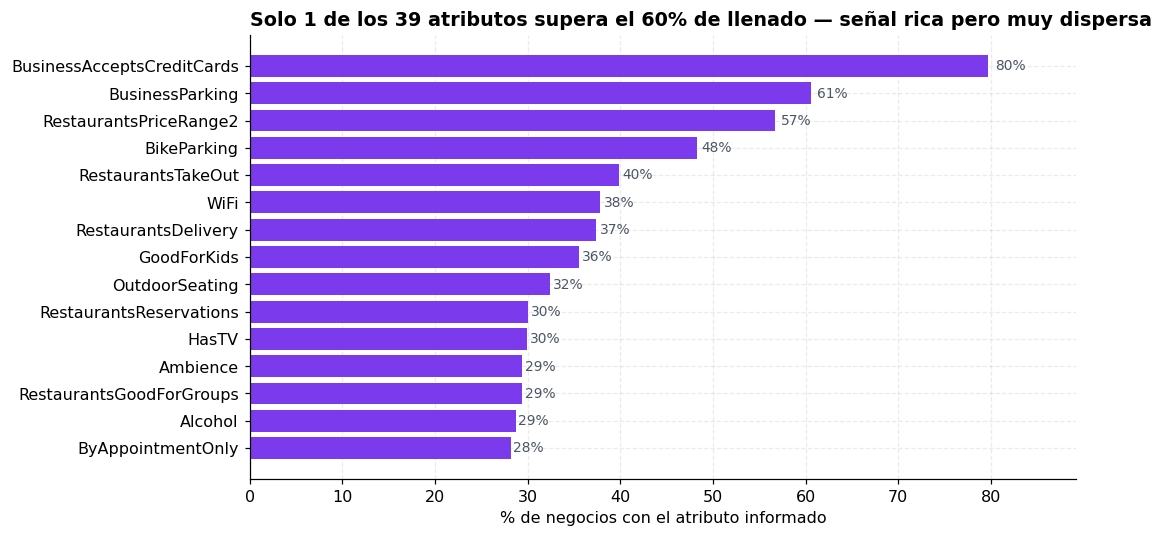

39 atributos en total; ejemplo de valores crudos:


+----------------------+------------------------------------------------------------+------------------------------------------------------------+
|RestaurantsPriceRange2|                                             BusinessParking|                                                    Ambience|
+----------------------+------------------------------------------------------------+------------------------------------------------------------+
|                     2|{'garage': False, 'street': False, 'validated': False, 'l...|                                                        NULL|
|                     1|{'garage': False, 'street': False, 'validated': False, 'l...|                                                        NULL|
|                     2|{'garage': False, 'street': False, 'validated': False, 'l...|{'touristy': False, 'hipster': False, 'romantic': False, ...|
+----------------------+------------------------------------------------------------+---------------------------------

In [9]:
attrs = T["business"].select("attributes.*")
n = T["business"].count()
cobertura = attrs.select([F.sum(F.col(c).isNotNull().cast("int")).alias(c) for c in attrs.columns]).first().asDict()
cob = (pd.Series(cobertura).sort_values(ascending=False).head(15) / n * 100)

fig, ax = plt.subplots(figsize=(10, 5))
viz.barras_h(ax, cob.index[::-1], cob.values[::-1], fmt="{:.0f}%",
             color=[viz.PALETA["morado"]] * 15)
ax.set_title("Solo 1 de los 39 atributos supera el 60% de llenado — señal rica pero muy dispersa")
ax.set_xlabel("% de negocios con el atributo informado")
plt.show()
print(f"{len(attrs.columns)} atributos en total; ejemplo de valores crudos:")
attrs.select("RestaurantsPriceRange2", "BusinessParking", "Ambience").where("RestaurantsPriceRange2 is not null").show(3, truncate=60)

El único atributo casi universal es si aceptan tarjeta (80%); le sigue el estacionamiento (61%) y de ahí todo cae rápido, con la mayoría debajo del 40%. Y ojo al formato: llegan como **strings crudos**, incluso diccionarios escritos en texto con los prefijos `u'...'` que delatan un export de Python 2.

Ese es el verdadero trabajo de limpieza de este dataset (la rúbrica lo pide justificado): en el notebook 04 parsearemos booleanos y anidados, y nos quedaremos con los atributos de cobertura razonable dentro del universo de restaurantes — precio, parking, ambiente, delivery — como features para el clustering de la Parte III.

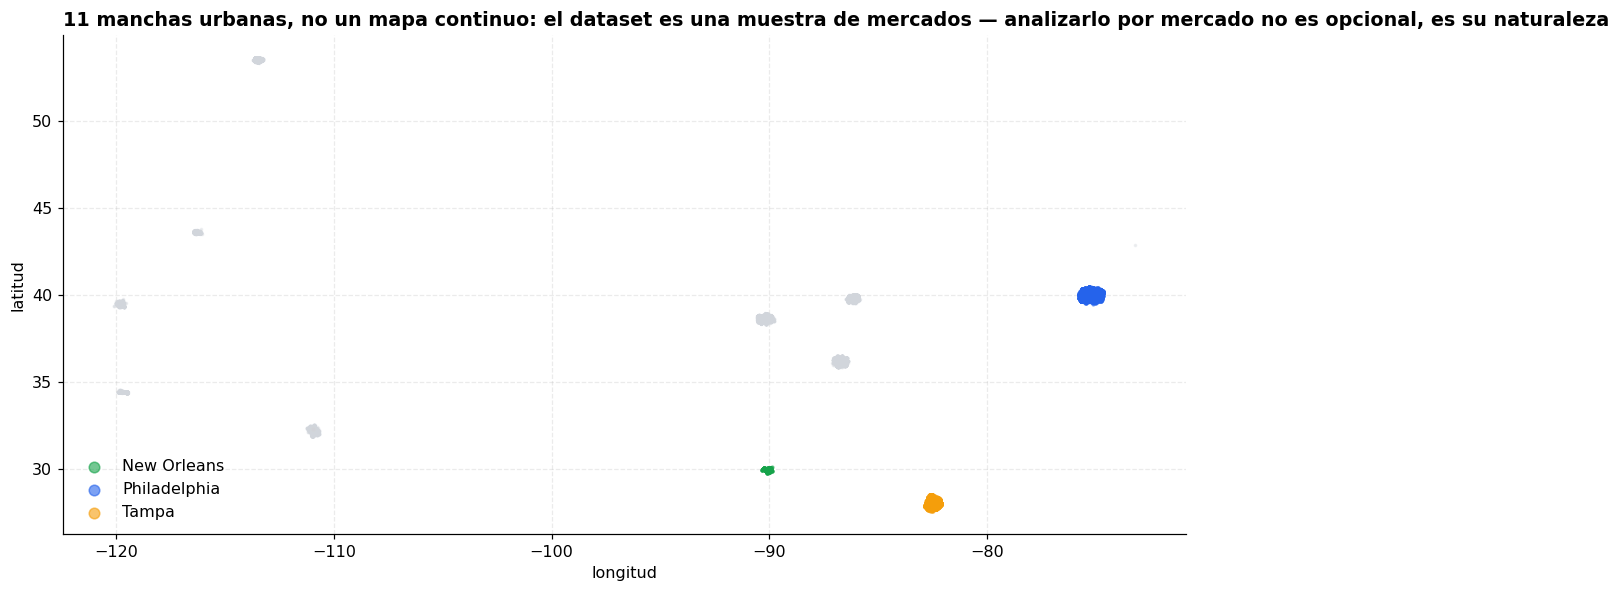

In [10]:
geo = T["business"].select("longitude", "latitude", "metro").sample(0.35, seed=42).toPandas()
fig, ax = plt.subplots(figsize=(11, 5.5))
for m, g in geo.groupby("metro"):
    destacado = m in viz.MERCADOS
    ax.scatter(g["longitude"], g["latitude"], s=3 if destacado else 2,
               color=viz.MERCADOS.get(m, viz.COLOR_RESTO), alpha=0.6 if destacado else 0.3,
               label=m if destacado else None)
ax.legend(markerscale=4, loc="lower left")
ax.set_title("11 manchas urbanas, no un mapa continuo: el dataset es una muestra de mercados — analizarlo por mercado no es opcional, es su naturaleza")
ax.set_xlabel("longitud"); ax.set_ylabel("latitud")
plt.show()

El mapa habla solo: esto no es "Estados Unidos", son **11 islas urbanas** separadas por miles de kilómetros sin nada entre medio. No existe un territorio continuo que analizar — la unidad natural del dataset es el mercado.

Nuestros tres mercados (a color) concentran masa y perfiles distintos; el resto (gris) no se bota: participa de este EDA y del análisis de flujos de la Parte V, donde la escala completa es precisamente el punto.

## 3. Usuarios y grafo social


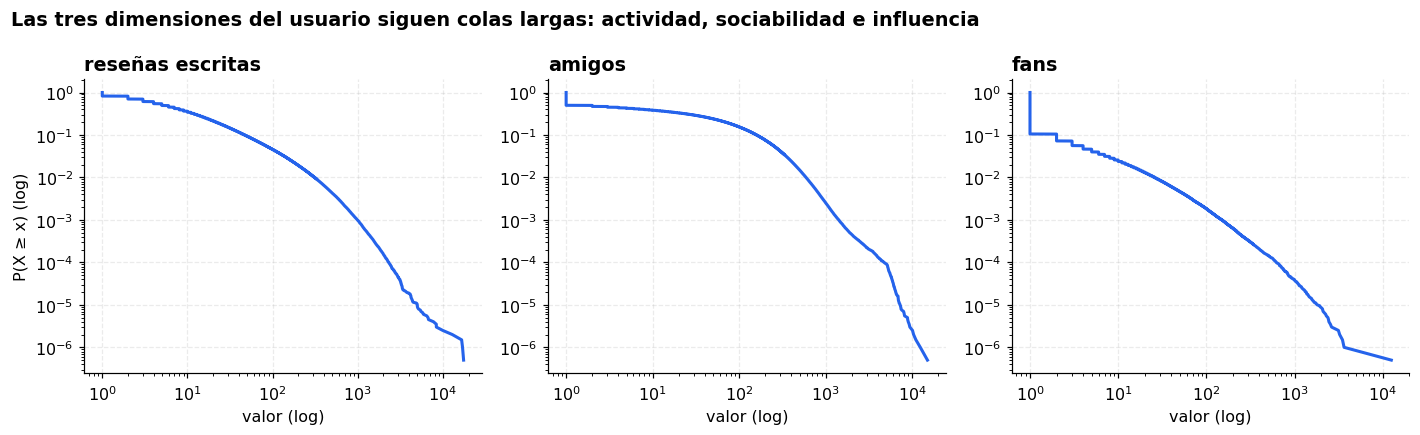

usuarios con 0 amigos: 44.2%  |  con 1 reseña: 17.4%


In [11]:
u = T["user"].select("review_count", "fans", "n_amigos").toPandas()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, titulo in [
    (axes[0], "review_count", "reseñas escritas"),
    (axes[1], "n_amigos", "amigos"),
    (axes[2], "fans", "fans"),
]:
    x, p = viz.ccdf(u[col].values)
    ax.loglog(np.maximum(x, 1), p, lw=2)
    ax.set_title(titulo); ax.set_xlabel("valor (log)")
axes[0].set_ylabel("P(X ≥ x) (log)")
fig.suptitle("Las tres dimensiones del usuario siguen colas largas: actividad, sociabilidad e influencia", x=0.01, ha="left", fontweight="bold")
plt.show()
print(f"usuarios con 0 amigos: {100*(u['n_amigos']==0).mean():.1f}%  |  con 1 reseña: {100*(u['review_count']==1).mean():.1f}%")

Las tres curvas caen casi en línea recta sobre ejes log-log: colas largas en actividad, en sociabilidad y en influencia. El usuario típico apenas participa — y un 44% no tiene ni un amigo en la plataforma — mientras una élite diminuta acumula miles de reseñas, conexiones y fans.

Es el patrón *hub* que motiva la semana 07: cuando la distribución es tan desigual, contar conexiones no mide influencia; importa **quién** te conecta. Por eso PageRank. El 44% de aislados también anticipa la forma del grafo social: una componente gigante rodeada de cientos de miles de nodos sueltos.

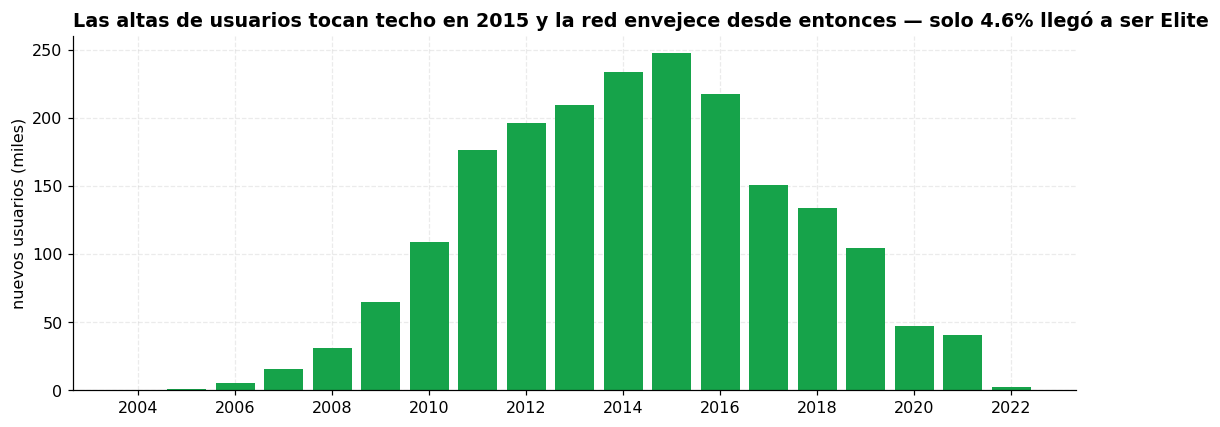

In [12]:
usr = T["user"]
pct_elite = usr.where("n_elite > 0").count() / usr.count() * 100
cohortes = usr.groupBy(F.year("yelping_since").alias("anio")).count().orderBy("anio").toPandas()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cohortes["anio"], cohortes["count"] / 1e3, color=viz.PALETA["verde"])
ax.set_xticks(range(2004, 2023, 2))
ax.set_title(f"Las altas de usuarios tocan techo en 2015 y la red envejece desde entonces — solo {pct_elite:.1f}% llegó a ser Elite")
ax.set_ylabel("nuevos usuarios (miles)")
plt.show()

La distinción **Elite** es escasa de verdad: 4.6% de las cuentas, curada a mano por Yelp año a año. Esa escasez nos viene perfecta: es una "etiqueta débil" de influencia que el algoritmo nunca verá.

La jugada para la Parte II: si nuestros top de PageRank/HITS resultan estar llenos de usuarios Elite sin que se lo hayamos dicho, tendremos evidencia independiente de que el ranking captura influencia real y no un artefacto del grafo.

In [13]:
g = usr.select("n_amigos")
n_nodos = usr.count()
con_amigos = g.where("n_amigos > 0").count()
aristas = g.agg(F.sum("n_amigos")).first()[0] / 2  # cada amistad aparece en ambos extremos
grado_medio = 2 * aristas / n_nodos
densidad = 2 * aristas / (n_nodos * (n_nodos - 1))
print(f"nodos (usuarios):            {n_nodos:>12,}")
print(f"  con ≥1 amigo:              {con_amigos:>12,}  ({100*con_amigos/n_nodos:.1f}%)")
print(f"aristas (amistades):         {aristas:>12,.0f}")
print(f"grado medio:                 {grado_medio:>12.1f}")
print(f"densidad:                    {densidad:>12.2e}")

nodos (usuarios):               1,987,897
  con ≥1 amigo:                 1,109,346  (55.8%)
aristas (amistades):           52,612,737
grado medio:                         52.9
densidad:                        2.66e-05


Los números imponen respeto: **52.6 millones de amistades** entre 2 millones de usuarios — grado medio 53, densidad 2.7×10⁻⁵. Es la radiografía de una red real según las semanas 16–17: enorme y dispersa a la vez.

La consecuencia práctica es de representación: la matriz de adyacencia densa ocuparía decenas de terabytes; la lista de aristas en Parquet, unos cientos de megas. Con listas de adyacencia trabajará la Parte II, y estos valores globales serán la vara contra la que midamos el subgrafo de los 3 mercados.

## 4. Reseñas: la tabla central


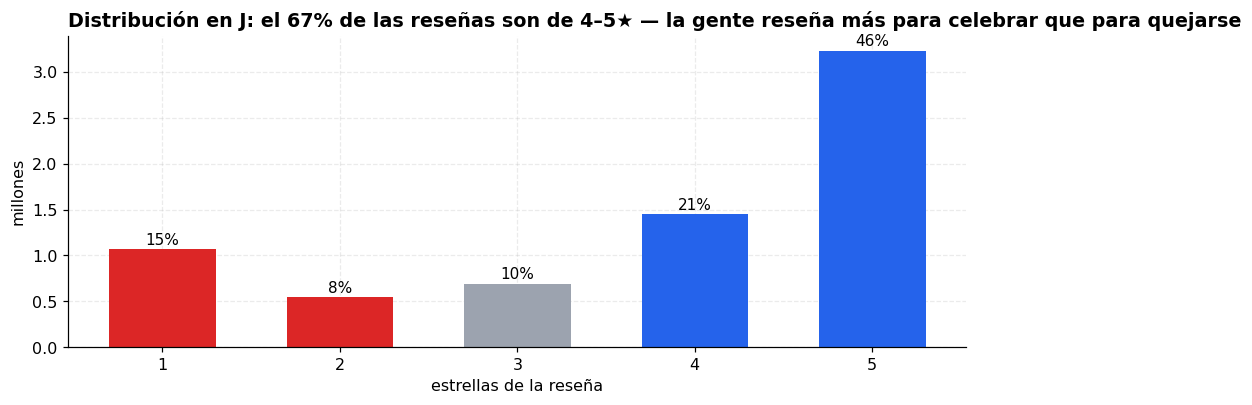

In [14]:
rs = T["review"].groupBy("stars").count().orderBy("stars").toPandas()
fig, ax = plt.subplots(figsize=(9, 3.8))
colores = [viz.PALETA["rojo"]]*2 + [viz.PALETA["gris"]] + [viz.PALETA["azul"]]*2
ax.bar(rs["stars"], rs["count"]/1e6, width=0.6, color=colores)
for x, v in zip(rs["stars"], rs["count"]):
    ax.text(x, v/1e6 + 0.05, f"{100*v/rs['count'].sum():.0f}%", ha="center", fontsize=10)
ax.set_title("Distribución en J: el 67% de las reseñas son de 4–5★ — la gente reseña más para celebrar que para quejarse")
ax.set_xlabel("estrellas de la reseña"); ax.set_ylabel("millones")
plt.show()

Casi la mitad de todo lo escrito en el dataset (46%) son cinco estrellas; el modo queja existe (15% de 1★) pero pierde por goleada: 67% del total es 4–5★. La forma en J no es un error a corregir — es cómo se comporta la gente: opina quien vivió algo extremo, no un cliente al azar.

Lo que sí nos toca es modelarlo: promedios inflados, recomendadores que aprenden de entusiastas (lo retomamos en la Parte VII) y una razón técnica concreta para sumar **Pearson** al coseno en el filtrado colaborativo (semana 10): al centrar por usuario, absorbe parte de ese optimismo de escala.

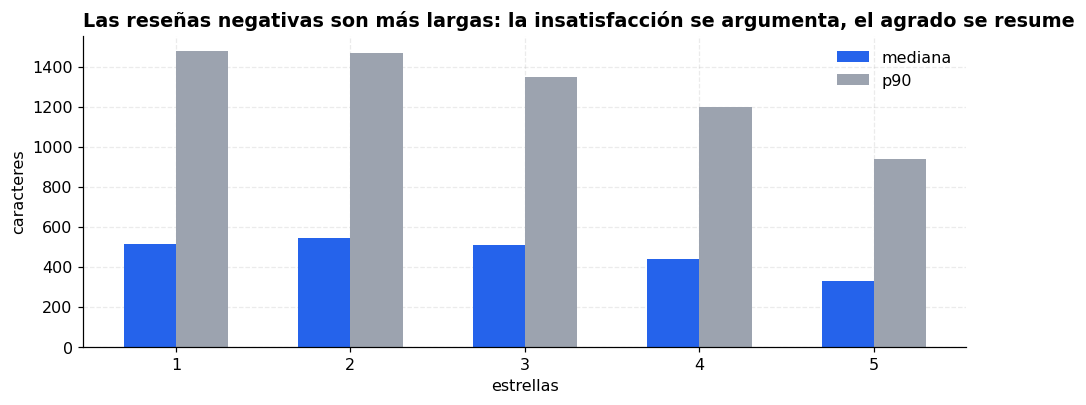

In [15]:
txt = (T["review"].select("stars", F.length("text").alias("chars"))
       .groupBy("stars").agg(F.expr("percentile(chars, 0.5)").alias("mediana"),
                              F.expr("percentile(chars, 0.9)").alias("p90")).orderBy("stars").toPandas())
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(txt["stars"] - 0.15, txt["mediana"], 0.3, label="mediana", color=viz.PALETA["azul"])
ax.bar(txt["stars"] + 0.15, txt["p90"], 0.3, label="p90", color=viz.PALETA["gris"])
ax.set_title("Las reseñas negativas son más largas: la insatisfacción se argumenta, el agrado se resume")
ax.set_xlabel("estrellas"); ax.set_ylabel("caracteres"); ax.legend()
plt.show()

Enojarse da más texto: la reseña mediana de 1★ trae ~515 caracteres contra ~330 de una de 5★ — un 60% más. La insatisfacción se argumenta; el agrado se despacha en dos líneas.

Para el content-based (semana 10) esto significa que el TF-IDF tendrá vocabulario más rico describiendo lo malo que lo bueno: el sistema "entenderá" mejor los disgustos de un usuario que sus gustos. Lo tendremos presente al interpretar similitudes en la Parte IV.

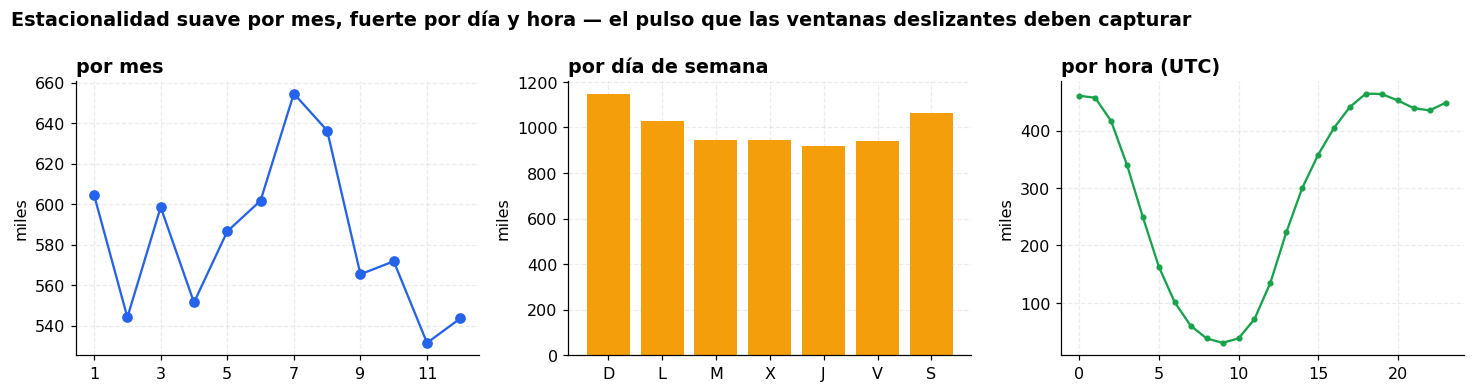

In [16]:
rev = T["review"]
por_mes = rev.groupBy(F.month("date").alias("mes")).count().orderBy("mes").toPandas()
por_dow = rev.groupBy(F.dayofweek("date").alias("dow")).count().orderBy("dow").toPandas()
por_hora = rev.groupBy(F.hour("date").alias("hora")).count().orderBy("hora").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
axes[0].plot(por_mes["mes"], por_mes["count"]/1e3, marker="o"); axes[0].set_title("por mes"); axes[0].set_xticks(range(1,13,2))
dias = ["D","L","M","X","J","V","S"]
axes[1].bar(dias, por_dow["count"]/1e3, color=viz.PALETA["naranja"]); axes[1].set_title("por día de semana")
axes[2].plot(por_hora["hora"], por_hora["count"]/1e3, marker=".", color=viz.PALETA["verde"]); axes[2].set_title("por hora (UTC)")
for a in axes: a.set_ylabel("miles")
fig.suptitle("Estacionalidad suave por mes, fuerte por día y hora — el pulso que las ventanas deslizantes deben capturar", x=0.01, ha="left", fontweight="bold")
plt.show()

Tres relojes conviven y los tres se ven a simple vista: el **año** (pico en julio, valles en febrero y noviembre), la **semana** (el domingo se escribe más — se reseña el fin de semana vivido) y el **día** (el valle de ~9 UTC es la madrugada estadounidense; el pico, la tarde local). Nota técnica: los timestamps están en UTC, y definir la zona horaria antes de ventanear es parte del diseño de un stream (semana 06).

Para la Parte V esto valida los tamaños de ventana que pide el enunciado (1h, 4h, 1 día) y nos deja el patrón base: los feriados — Mardi Gras incluido — deberán aparecer como anomalías *sobre* estos ciclos, no confundidos con ellos.

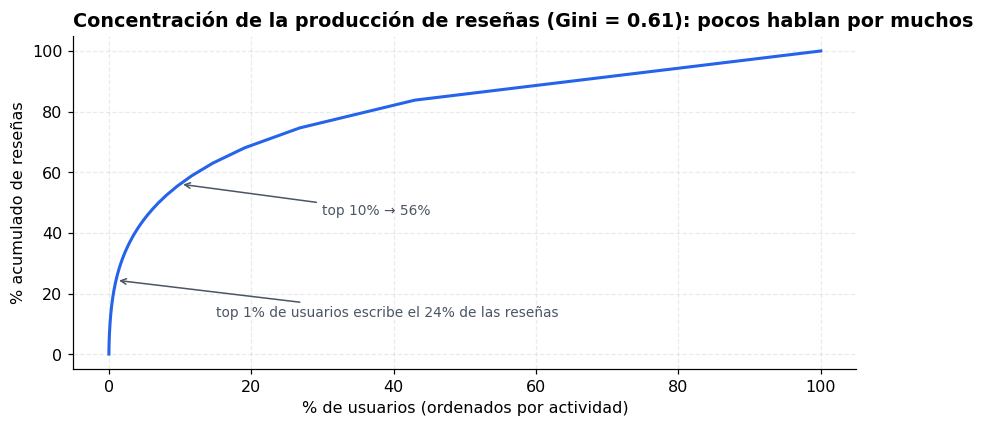

In [17]:
por_usuario = T["review"].groupBy("user_id").count().toPandas()["count"].values
v = np.sort(por_usuario)[::-1]
acum = np.cumsum(v) / v.sum()
top1, top10 = acum[int(len(v)*0.01)], acum[int(len(v)*0.10)]
gini = 1 - 2 * np.trapezoid(np.cumsum(np.sort(por_usuario))/por_usuario.sum(), dx=1/len(v))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.linspace(0, 100, len(acum)), acum*100, lw=2)
viz.anotar(ax, f"top 1% de usuarios escribe el {top1*100:.0f}% de las reseñas", (1, top1*100), (15, top1*100-12))
viz.anotar(ax, f"top 10% → {top10*100:.0f}%", (10, top10*100), (30, top10*100-10))
ax.set_title(f"Concentración de la producción de reseñas (Gini = {gini:.2f}): pocos hablan por muchos")
ax.set_xlabel("% de usuarios (ordenados por actividad)"); ax.set_ylabel("% acumulado de reseñas")
plt.show()

La curva lo dice sin anestesia: el **1% más activo escribe el 24% de todas las reseñas**, y el top 10% llega al **56%**. Más de la mitad de lo que "dice Yelp" lo dice una décima parte de sus usuarios (Gini = 0.61 — en desigualdad de ingresos, un país con ese número estaría entre los más desiguales del mundo).

Para nosotros es un arma de doble filo. Por un lado, sostiene el filtrado colaborativo: esos usuarios densos son la columna vertebral de la matriz usuario×negocio. Por otro, abre la pregunta de equidad que retomaremos en la Parte VII: ¿el sistema recomienda lo que le gusta a la gente, o lo que le gusta a los que más escriben?

## 5. Check-ins y tips: los flujos de eventos


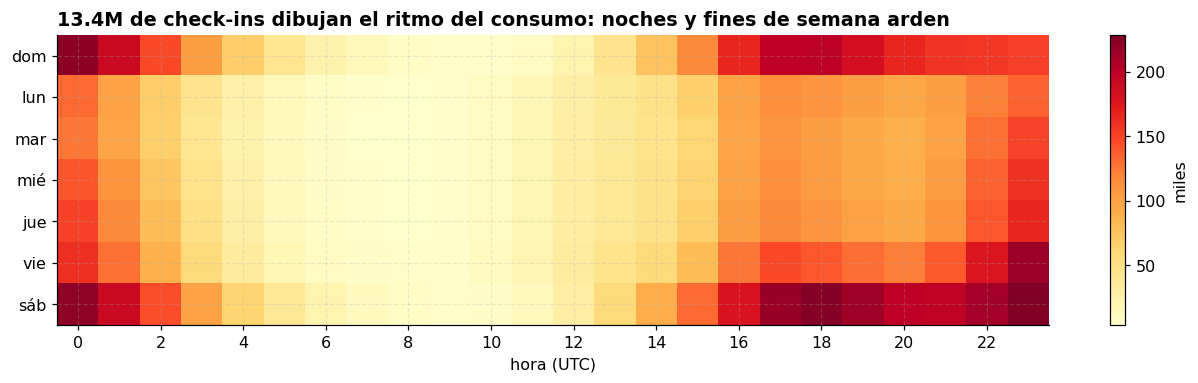

In [18]:
chk = (T["checkin"].groupBy(F.dayofweek("ts").alias("dow"), F.hour("ts").alias("hora"))
       .count().toPandas().pivot(index="dow", columns="hora", values="count"))
fig, ax = plt.subplots(figsize=(12, 3.6))
im = ax.imshow(chk / 1e3, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(7), ["dom","lun","mar","mié","jue","vie","sáb"])
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("hora (UTC)")
ax.set_title("13.4M de check-ins dibujan el ritmo del consumo: noches y fines de semana arden")
fig.colorbar(im, label="miles")
plt.show()

El mapa de calor se lee como el día de un restaurante: el calor arranca al mediodía local (~16 UTC), crece toda la tarde y revienta a la hora de la cena — la franja 22–1 UTC, que en hora del Este es entre las 5 y las 8 de la noche. La madrugada (6–12 UTC) está muerta. Y los fines de semana el patrón se intensifica: viernes y sábado por la noche son las celdas más oscuras de todo el mapa. Un detalle curioso del UTC: parte de la "noche del sábado" local cae en la fila del domingo, porque a medianoche UTC el sábado estadounidense todavía no termina.

A diferencia de las reseñas, el check-in no opina: registra presencia física, sin el sesgo de "solo hablan los extremos". Por eso esta tabla — 13.4 millones de eventos puros de negocio + timestamp — será nuestro stream estrella en la Parte V: Count-Min Sketch para responder "¿qué negocios son tendencia en esta ventana?" y DGIM sobre el flujo binarizado, tal como los plantea la semana 06.

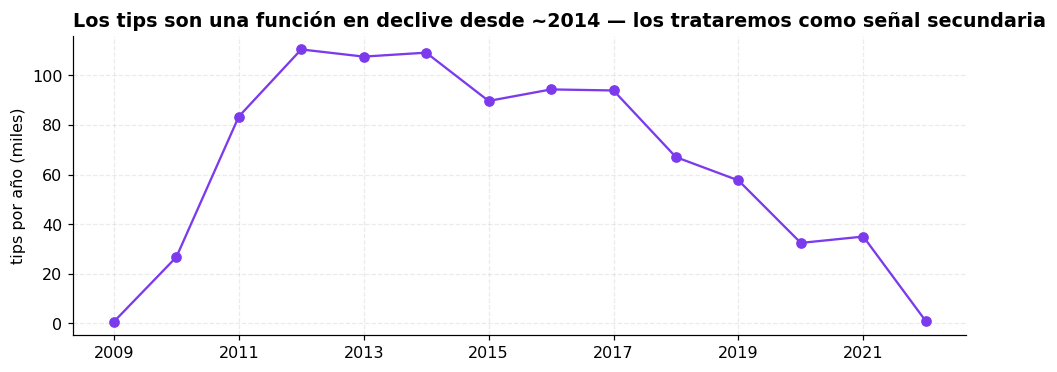

In [19]:
ta = T["tip"].groupBy(F.year("date").alias("anio")).count().orderBy("anio").toPandas()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(ta["anio"], ta["count"]/1e3, marker="o", color=viz.PALETA["morado"])
ax.set_xticks(range(2009, 2023, 2))
ax.set_title("Los tips son una función en declive desde ~2014 — los trataremos como señal secundaria")
ax.set_ylabel("tips por año (miles)")
plt.show()

Los tips tuvieron su época dorada entre 2012 y 2014 — más de 100 mil por año — y de ahí en adelante el declive es sostenido: para 2020 quedaban ~33 mil, un 70% menos que en el pico. Es una funcionalidad que la plataforma claramente dejó de empujar (el punto de 2022 es el corte de enero, no un colapso).

Decisión informada: no construimos análisis principales sobre tips. Los guardamos como texto auxiliar por si algún negocio con pocas reseñas necesita refuerzo de contenido en el content-based de la Parte IV.

## 6. Calidad de datos: hallazgos y decisiones de tratamiento


In [20]:
biz, rev = T["business"], T["review"]
chequeos = {
    "negocios sin categorías": biz.where("categories is null").count(),
    "negocios con coordenadas fuera de EE.UU./Canadá": biz.where(
        "latitude < 24 or latitude > 58 or longitude < -125 or longitude > -65").count(),
    "postal_code vacío": biz.where("postal_code = '' or postal_code is null").count(),
    "postal_code no numérico (formato canadiense)": biz.where("postal_code rlike '[A-Za-z]'").count(),
    "reseñas con texto vacío": rev.where("text = '' or text is null").count(),
    "reseñas con fecha fuera de rango (2004–2022)": rev.where(
        "date < '2004-10-01' or date > '2022-01-20'").count(),
    "reseñas con stars fuera de 1–5": rev.where("stars < 1 or stars > 5").count(),
}
for k, v in chequeos.items():
    print(f"{k:55s} {v:>10,}")

negocios sin categorías                                        103
negocios con coordenadas fuera de EE.UU./Canadá                  0
postal_code vacío                                               73
postal_code no numérico (formato canadiense)                 5,556
reseñas con texto vacío                                          0
reseñas con fecha fuera de rango (2004–2022)                     0
reseñas con stars fuera de 1–5                                   0


El veredicto general es tranquilizador: **0** coordenadas fuera de rango, **0** reseñas sin texto, **0** fechas imposibles, **0** estrellas inválidas. La suciedad real es poca y está localizada — y para cada hallazgo dejamos decidido qué haremos y por qué:

| Hallazgo | Cuántos | Decisión | Por qué |
|---|---|---|---|
| negocios sin `categories` | 103 (0.07%) | excluir del universo temático | sin giro declarado no podemos saber si son restaurantes |
| `postal_code` vacío | 73 | quedan fuera del cruce ACS | sin ZIP no hay demografía que asignar; son marginales |
| `postal_code` con letras (formato canadiense) | 5,556 | fuera del cruce ACS | el censo de EE.UU. no cubre Canadá — es Edmonton, que ya está fuera del núcleo |
| atributos como strings crudos (`u'True'`, dicts en texto) | 39 columnas | parseo dedicado en el notebook 04 | son las features del clustering; sin parseo no hay Parte III |
| sesgo en J de los ratings | estructural | se modela, no se "corrige" | es el fenómeno, no un error: Pearson en la Parte IV y discusión en la VII |
| duplicados / reseñas huérfanas | 0 | nada que hacer | verificado en el notebook 02: identidades curadas de origen |

## Resumen del notebook

Recorrimos el dataset completo, variable por variable, y esto es lo que nos llevamos:

1. **El dataset son 11 islas, no un país**: mercados metropolitanos separados — analizarlo por mercado no es una elección nuestra, es su naturaleza. Respalda el diseño de 3 mercados completos.
2. **Colas largas en todo**: la mitad de los negocios tiene ≤15 reseñas (p99 = 473), el 44% de los usuarios no tiene amigos, y el top 10% de usuarios escribe el 56% de las reseñas (Gini 0.61). El conteo bruto no mide importancia → ahí entran PageRank/HITS (Parte II).
3. **El tema apunta al corazón de la data**: `Restaurants` es la categoría #1 (52,268 negocios, 35%); las etiquetas son multi-categoría, así que el filtro por token exacto es seguro (sensibilidad `∪ Food` en el notebook 04).
4. **El grafo social es serio**: 52.6M de amistades, grado medio 53, densidad 2.7×10⁻⁵ — red gigante y dispersa que obliga a representaciones por listas (Parte II).
5. **Sesgos a modelar, no a borrar**: 67% de reseñas son 4–5★ (forma en J), las negativas traen 60% más texto, y solo 4.6% de usuarios fue Elite — decisiones ya tomadas para Partes IV y VII.
6. **Tres relojes temporales** (año/semana/día) + 13.4M check-ins con patrón noche/findes → la materia prima de la Parte V.
7. **La suciedad real está en los atributos**: solo 1 de 39 supera el 60% de llenado y vienen como strings de Python 2 — el plan de tratamiento quedó definido en la sección 6.

**Siguiente (notebook 04):** descargar las fuentes externas y hacerles **su propio EDA** (cobertura, calidad y qué aporta cada una — mismo estándar que aquí), validar filtro y recorte con análisis de sensibilidad, parsear atributos y construir las tablas gold: grafo social, grafo bipartito, matriz usuario×negocio, features y stream.

In [21]:
spark.stop(); print("EDA global completo ✅")

EDA global completo ✅
